In [1]:
import sys, os
project_root = os.path.abspath("..") 
sys.path.insert(0, project_root)
from heap import coincidences as coinc
from pathlib import Path

In [2]:
#Demonstation notebook for the functions of coincidences.py, including function to determine and correct time offsets between telescopes and match coincidences afterwards

dp_ph1024.bpp_2.module_253: 1 files found
  -> ../test_data/20260709/obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd/start_2026-07-09T08:35:53Z.dp_ph1024.bpp_2.module_253.seqno_0.pff
Data read in, number of events:  3452
Number of Events with package loss:  0  ( 0.0 %)


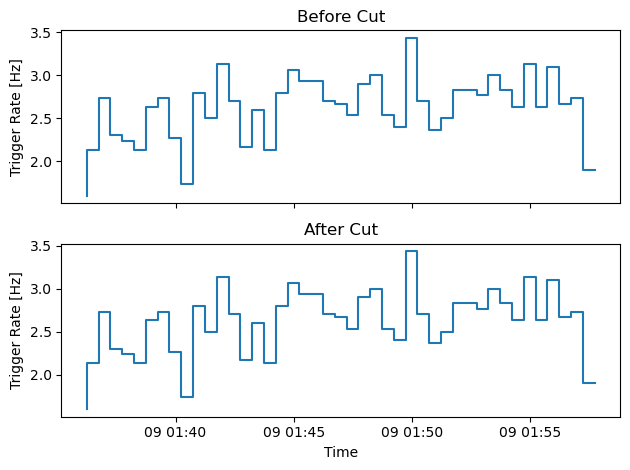

Rate spikes at:  DatetimeIndex(['2026-07-09 01:36:44.468430996-07:00',
               '2026-07-09 01:37:14.468430996-07:00',
               '2026-07-09 01:37:44.468430996-07:00',
               '2026-07-09 01:38:14.468430996-07:00',
               '2026-07-09 01:38:44.468430996-07:00',
               '2026-07-09 01:39:14.468430996-07:00',
               '2026-07-09 01:39:44.468430996-07:00',
               '2026-07-09 01:40:14.468430996-07:00',
               '2026-07-09 01:41:14.468430996-07:00',
               '2026-07-09 01:41:44.468430996-07:00',
               '2026-07-09 01:42:14.468430996-07:00',
               '2026-07-09 01:42:44.468430996-07:00',
               '2026-07-09 01:43:14.468430996-07:00',
               '2026-07-09 01:43:44.468430996-07:00',
               '2026-07-09 01:44:14.468430996-07:00',
               '2026-07-09 01:44:44.468430996-07:00',
               '2026-07-09 01:45:14.468430996-07:00',
               '2026-07-09 01:45:44.468430996-07:00',
           

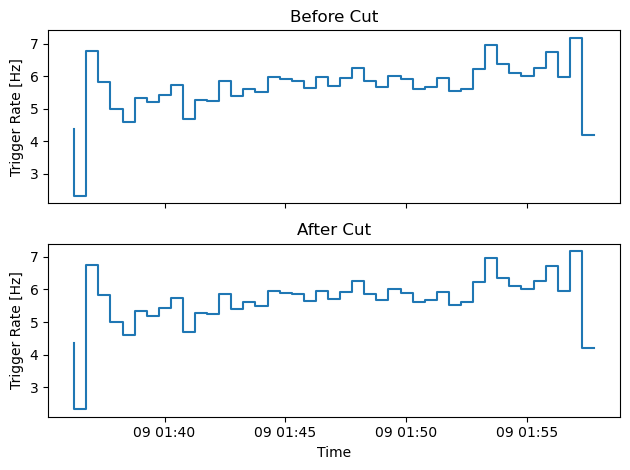

Rate spikes at:  DatetimeIndex(['2026-07-09 01:36:15.696494102-07:00',
               '2026-07-09 01:36:45.696494102-07:00',
               '2026-07-09 01:37:15.696494102-07:00',
               '2026-07-09 01:37:45.696494102-07:00',
               '2026-07-09 01:38:15.696494102-07:00',
               '2026-07-09 01:38:45.696494102-07:00',
               '2026-07-09 01:39:15.696494102-07:00',
               '2026-07-09 01:39:45.696494102-07:00',
               '2026-07-09 01:40:15.696494102-07:00',
               '2026-07-09 01:40:45.696494102-07:00',
               '2026-07-09 01:41:15.696494102-07:00',
               '2026-07-09 01:41:45.696494102-07:00',
               '2026-07-09 01:42:15.696494102-07:00',
               '2026-07-09 01:42:45.696494102-07:00',
               '2026-07-09 01:43:15.696494102-07:00',
               '2026-07-09 01:43:45.696494102-07:00',
               '2026-07-09 01:44:15.696494102-07:00',
               '2026-07-09 01:44:45.696494102-07:00',
           

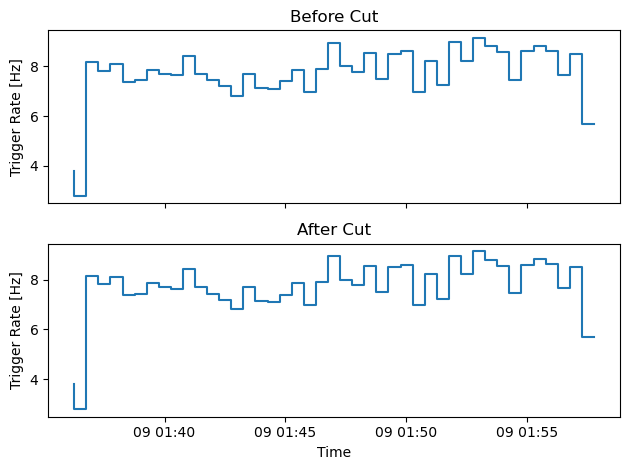

Rate spikes at:  DatetimeIndex(['2026-07-09 01:36:15.546175957-07:00',
               '2026-07-09 01:36:45.546175957-07:00',
               '2026-07-09 01:37:15.546175957-07:00',
               '2026-07-09 01:37:45.546175957-07:00',
               '2026-07-09 01:38:15.546175957-07:00',
               '2026-07-09 01:38:45.546175957-07:00',
               '2026-07-09 01:39:15.546175957-07:00',
               '2026-07-09 01:39:45.546175957-07:00',
               '2026-07-09 01:40:15.546175957-07:00',
               '2026-07-09 01:40:45.546175957-07:00',
               '2026-07-09 01:41:15.546175957-07:00',
               '2026-07-09 01:41:45.546175957-07:00',
               '2026-07-09 01:42:15.546175957-07:00',
               '2026-07-09 01:42:45.546175957-07:00',
               '2026-07-09 01:43:15.546175957-07:00',
               '2026-07-09 01:43:45.546175957-07:00',
               '2026-07-09 01:44:15.546175957-07:00',
               '2026-07-09 01:44:45.546175957-07:00',
           

In [3]:
#We have all pff files for one night, one source in a directory, e.g. obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd/
#There could be multiple files for one telescope (e.g. before and mafter meridian flip)
#Every telescope has a module number which is part of file's name
#Assuming all pff files in the directory are not empty (could add condition to catch that later)
base_dir=Path("../test_data/20260709/obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd/") #Path for data files
#corresponding module numbers for the telescopes
#module_str includes the dp_ph1024 data product tag so the glob doesn't also pick up the ph256/img8/img16 files for the same module
#rate_cut (Hz) is spike_cut's trigger-rate threshold; picked comfortably above each telescope's observed rate since this run has no real spikes
data_winter, timestamps_winter = coinc.load_telescope_tv("dp_ph1024.bpp_2.module_253", base_dir, rate_cut=20, plotting=True)
data_heli, timestamps_heli = coinc.load_telescope_tv("dp_ph1024.bpp_2.module_250", base_dir, rate_cut=20, plotting=True)
data_fern, timestamps_fern = coinc.load_telescope_tv("dp_ph1024.bpp_2.module_252", base_dir, rate_cut=20, plotting=True)
#Reads in all data files for corresponding telescope, runs pre_cleaning functions, combines multiple data files, returns data and timestamps

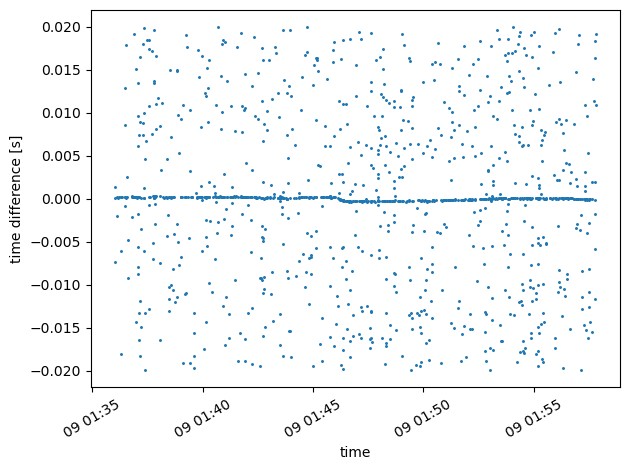

(array([1.78358616e+09, 1.78358616e+09, 1.78358616e+09, ...,
        1.78358747e+09, 1.78358747e+09, 1.78358747e+09]),
 array([1.78358616e+09, 1.78358616e+09, 1.78358616e+09, ...,
        1.78358747e+09, 1.78358747e+09, 1.78358747e+09]),
 array([ 0.00134683, -0.00735497,  0.00012708, ...,  0.01833487,
         0.01096392,  0.01917005]))

In [4]:
#Taking Coincidences between Winter and Heli as an example:
#First check the timing offset by looking for coincidences within a large time window (default 20 ms), plotting timeing difference dt against timestamps of either telescope
coinc.time_offset(timestamps_winter,timestamps_heli,plotting=True)
#If the offset drifts over the course of the run, coincident events will show varying time differences -> no clear peak in the dt distribution
#-> correct_time() below fits and removes any such drift

Offset: RMS=  0.00017 s, std= 0.00017 s
Corrected Offset: RMS=  0.0 s, std= 0.0 s


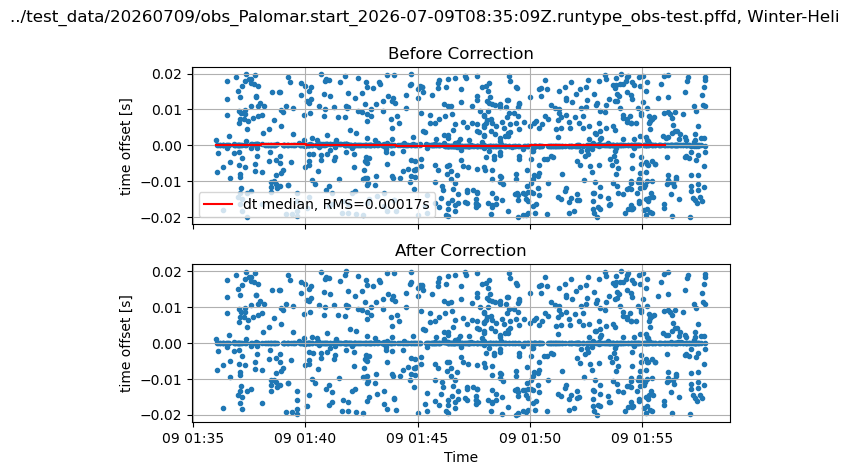

In [5]:
#We localize the bold line by taking the median of dt over a certain time window containing enough data point (default 120 s), see red line in top plot
#Subtracting median from all winter timestamps
#Making dt vs time plot again to check if time offset is now constant around 0
#Returning corrected timestamps for winter
timestamps_winter_corr=coinc.correct_time(timestamps_winter,timestamps_heli,plot_name="Winter-Heli",base_dir=base_dir,plotting=True)
#We see that the red line fits the offset well -> bin_width of 120 s good enough, may need to adjust it for other nights
#Correction worked: Constant offset around 0, RMS=0

In [6]:
#Now we use the corrected winter timestamps to do the actual coincidence matching with a small time window (default 1ms, needs to be adjusted maybe)
#Input timestamps and data of both telescopes (use corrected timestamps for telescope 1/winter)
#Returns timestamps (unix) and data of coincident events for both telescopes
time_coinc_winter, data_coinc_winter,time_coinc_heli,data_coinc_heli=coinc.match_coinc(timestamps_winter_corr,data_winter,timestamps_heli,data_heli)

Number of events for telescope 1: 3452
Number of events for telescope 2: 7475
Number of coincident events within 0.001s: 468 ( ~13.6% of all telescope 1 events and ~6.3% of all telescope 2 events.)


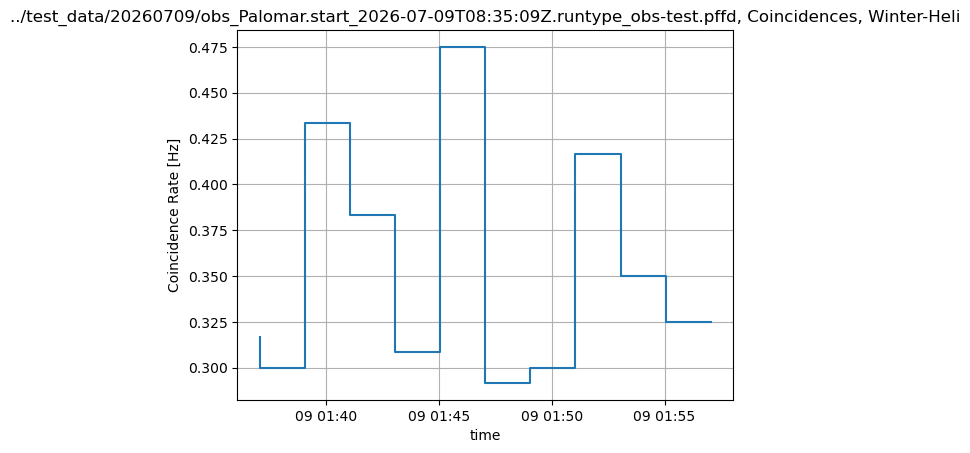

(array([1.78358622e+09, 1.78358634e+09, 1.78358646e+09, 1.78358658e+09,
        1.78358670e+09, 1.78358682e+09, 1.78358694e+09, 1.78358706e+09,
        1.78358718e+09, 1.78358730e+09, 1.78358742e+09]),
 array([0.31666667, 0.3       , 0.43333333, 0.38333333, 0.30833333,
        0.475     , 0.29166667, 0.3       , 0.41666667, 0.35      ,
        0.325     ]))

In [7]:
#Calculating and plotting the coincident trigger rate between Winter and Heli, returns binned unix timestamps and rate in Hz
#Using a smaller bin_width than the original demo since this run is only ~22 minutes long
coinc.coinc_rate(time_coinc_winter,"Winter-Heli",base_dir,bin_width=120,plotting=True)

Offset: RMS=  0.00016 s, std= 0.00016 s
Corrected Offset: RMS=  1e-05 s, std= 1e-05 s


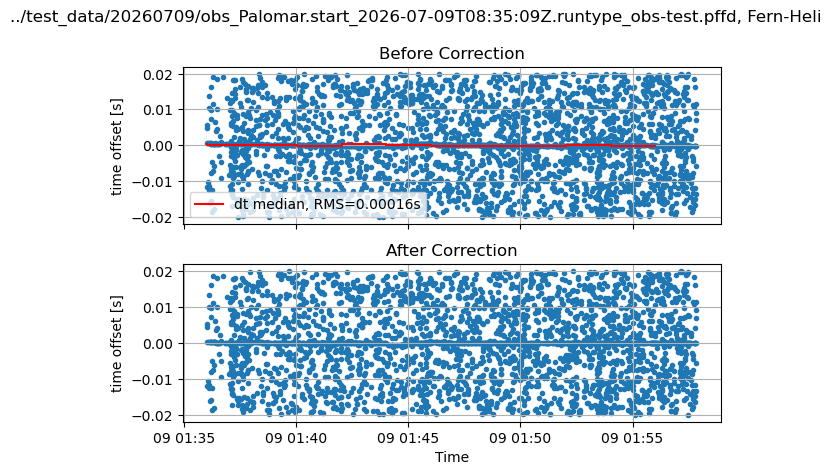

In [8]:
#To calculate the 3-telescope coincidences we first need to correct the timestamps of 2 telescopes relative to the 3rd
#We already corrected timestamps for winter relative to Heli, so let's also correct Fern timestamps relative to Heli
timestamps_fern_corr=coinc.correct_time(timestamps_fern,timestamps_heli,plot_name="Fern-Heli",base_dir=base_dir,plotting=True)

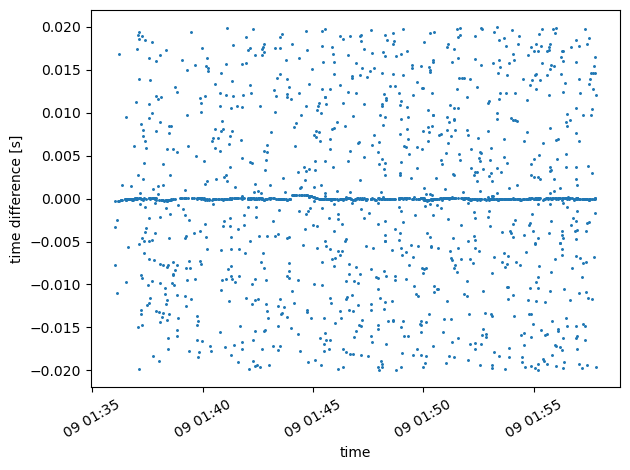

(array([1.78358616e+09, 1.78358616e+09, 1.78358616e+09, ...,
        1.78358747e+09, 1.78358747e+09, 1.78358747e+09]),
 array([1.78358616e+09, 1.78358616e+09, 1.78358616e+09, ...,
        1.78358747e+09, 1.78358747e+09, 1.78358747e+09]),
 array([-3.30758095e-03, -7.75146484e-03, -2.69412994e-04, ...,
        -1.28746033e-05,  1.20711327e-02, -1.95887089e-02]))

In [9]:
#Since we corrected winter and fern relative to Heli there should be also not offset between winter and fern now
#Checking:
coinc.time_offset(timestamps_winter_corr,timestamps_fern_corr,plotting=True)

In [10]:
#Calclating coincidences between all 3 telescopes using corrected timestamps for winter and fern
#First determine coincidences between first 2 telelscopes and then match coincident timestamps with 3rd telescopes
#Return coincident timestamps and data of all 3 telescopes
time_coinc3_winter,data_coinc3_winter,time_coinc3_heli,data_coinc3_heli,time_coinc3_fern,data_coinc3_fern=coinc.match_coinc3(timestamps_winter_corr,data_winter,timestamps_heli,data_heli,timestamps_fern_corr,data_fern)

Number of events T1: 3452
Number of events T2: 7475
Number of events T3: 10131
Number of triple coincidences within 0.001s: 337 (~9.8% of T1, ~4.5% of T2, ~3.3% of T3)


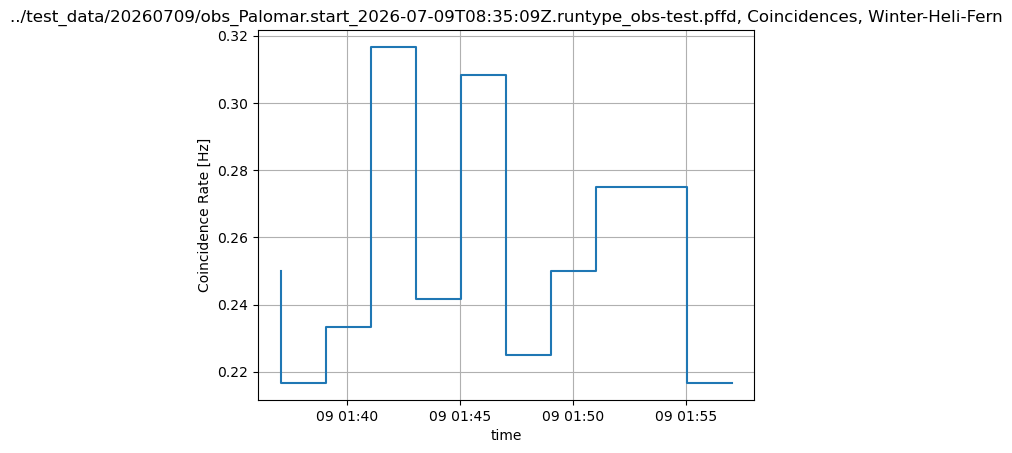

(array([1.78358622e+09, 1.78358634e+09, 1.78358646e+09, 1.78358658e+09,
        1.78358670e+09, 1.78358682e+09, 1.78358694e+09, 1.78358706e+09,
        1.78358718e+09, 1.78358730e+09, 1.78358742e+09]),
 array([0.25      , 0.21666667, 0.23333333, 0.31666667, 0.24166667,
        0.30833333, 0.225     , 0.25      , 0.275     , 0.275     ,
        0.21666667]))

In [11]:
#Determine and plot 3-telescope coincidence rate:
coinc.coinc_rate(time_coinc3_winter,"Winter-Heli-Fern",base_dir,bin_width=120,plotting=True)